# Historical and future FPC: monthly climatology versus annual structural output

This notebook applies one consistent workflow to:

- **Historical:** `mfpc_pft_avg_1971_2000.out` versus `fpc1971to2000.txt`
- **Future (GFDL-ESM4 SSP585):** `mfpc_pft_avg_2071_2100_monthly_mean.out` versus `GFDL-ESM4_SSP585_fpc2071to2100.txt`

For each grid cell and field, it compares the supplied annual value with:

1. the mean of the 12 monthly climatological values; and
2. the maximum of the 12 monthly climatological values.

The signed difference is always **monthly-derived statistic − supplied annual value**.

## 👉 Conclusion
The result is actually very clear: 
- Annual files are **not the arithmetic annual mean  of the monthly FPC values**. 
- They behave much more like a **peak growing-season** diagnostic.

## 🌿 Interpretation (after checking with Jing Tang)

These products do not represent exactly the same temporal quantity. 
- 🍁 the **monthly values** are daily, **phenology-adjusted values** averaged within each month,
- 🌳 the **annual files** contain 30-year means of year-end **structural values**.


Therefore, 

- 🔵 a systematic negative difference for the 12-month mean is expected. 
- 🔺 The monthly maximum may closely approximate the structural value when the phenology factor approaches one. 
*Note: however, it is not mathematically identical to the annual diagnostic.*


## 1. Setup and input files


In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

try:
    import cartopy.crs as ccrs
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False

BASE_DIR = Path.home() / "BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS"
OUTPUT_DIR = Path("06-original_vs_monthly_comparison_figures/annual_vs_monthly_comparison")
SAVE_FIGURES = True
CHUNKSIZE = 250_000
ROUNDING_TOLERANCE = 0.5e-3 + 1e-12
KEYS = ["Lon", "Lat"]
MAP_FIELDS = ["Total", "Natural_sum", "Peatland_sum"]
SEASONAL_FIELDS = ["BNS", "TeBS", "SPDS", "HSS", "IBS", "WetGRS", "pmoss", "GRT", "C3G"]

NATURAL_PFTS = [
    "BNE", "BINE", "BNS", "TeNE", "TeBE", "IBS", "TeBS", "C3G",
    "HSE", "HSS", "LSE", "LSS", "GRT", "EPDS", "SPDS", "CLM",
]
PEATLAND_PFTS = ["pLSE", "pLSS", "pCLM", "WetGRS", "pmoss", "C3G_wet", "C4G_wet"]
EVERGREEN_PFTS = ["BNE", "BINE", "TeNE"]

PERIODS = {
    "historical": {
        "label": "Historical",
        "start_year": 1971,
        "end_year": 2000,
        "monthly_file": BASE_DIR / "mfpc_pft_avg_1971_2000.out",
        "annual_file": BASE_DIR / "fpc1971to2000.txt",
    },
    "future": {
        "label": "GFDL-ESM4 SSP585",
        "start_year": 2071,
        "end_year": 2100,
        "monthly_file": BASE_DIR / "mfpc_pft_avg_2071_2100_monthly_mean.out",
        "annual_file": BASE_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt",
    },
}

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for config in PERIODS.values():
    print(f"{config['label']}: {config['monthly_file'].name} vs {config['annual_file'].name}")
    assert config["monthly_file"].exists(), f"Missing: {config['monthly_file']}"
    assert config["annual_file"].exists(), f"Missing: {config['annual_file']}"
print(f"Cartopy available: {HAS_CARTOPY}")


Historical: mfpc_pft_avg_1971_2000.out vs fpc1971to2000.txt
GFDL-ESM4 SSP585: mfpc_pft_avg_2071_2100_monthly_mean.out vs GFDL-ESM4_SSP585_fpc2071to2100.txt
Cartopy available: True


## 2. Shared loading and validation functions

The loader detects whether a `Year` column is present. If so, it calculates the monthly climatology over the requested 30-year period in chunks. Otherwise, it validates the file as an existing 12-month climatology.


In [2]:
def read_monthly_climatology(path, start_year, end_year, chunksize=250_000):
    header = pd.read_csv(path, sep=r"\s+", nrows=0).columns.tolist()
    required = {"Lon", "Lat", "Month", "Total"}
    missing = required.difference(header)
    if missing:
        raise ValueError(f"Missing required columns in {path.name}: {sorted(missing)}")

    has_year = "Year" in header
    value_columns = [column for column in header if column not in KEYS + ["Year", "Month"]]
    repeated_headers = 0

    if has_year:
        sum_parts, count_parts = [], []
        for raw in pd.read_csv(path, sep=r"\s+", dtype=str, chunksize=chunksize):
            year = pd.to_numeric(raw["Year"], errors="coerce")
            repeated_headers += int(year.isna().sum())
            raw = raw.loc[year.between(start_year, end_year)].copy()
            if raw.empty:
                continue
            raw["Year"] = year.loc[raw.index]
            numeric_columns = KEYS + ["Month"] + value_columns
            raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors="coerce")
            if raw[numeric_columns].isna().any().any():
                bad = raw.loc[raw[numeric_columns].isna().any(axis=1)].head()
                raise ValueError(f"Non-numeric or missing monthly values found:\n{bad}")
            grouped = raw.groupby(KEYS + ["Month"])[value_columns]
            sum_parts.append(grouped.sum())
            count_parts.append(grouped.count())

        if not sum_parts:
            raise ValueError(f"No records found for {start_year}–{end_year} in {path}")
        sums = pd.concat(sum_parts).groupby(level=[0, 1, 2]).sum()
        counts = pd.concat(count_parts).groupby(level=[0, 1, 2]).sum()
        monthly = (sums / counts).reset_index()
        count_table = counts.reset_index()
        expected_years = end_year - start_year + 1
        if not np.all(count_table[value_columns].to_numpy() == expected_years):
            raise ValueError("Some coordinate–month–field combinations do not contain the expected number of years.")
    else:
        raw = pd.read_csv(path, sep=r"\s+", dtype=str)
        month = pd.to_numeric(raw["Month"], errors="coerce")
        repeated_headers = int(month.isna().sum())
        raw = raw.loc[month.notna()].copy()
        raw["Month"] = month.loc[raw.index].astype(int)
        numeric_columns = KEYS + ["Month"] + value_columns
        raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors="coerce")
        if raw[numeric_columns].isna().any().any():
            bad = raw.loc[raw[numeric_columns].isna().any(axis=1)].head()
            raise ValueError(f"Non-numeric or missing monthly values found:\n{bad}")
        monthly = raw[KEYS + ["Month"] + value_columns].copy()

    if monthly.duplicated(KEYS + ["Month"]).any():
        raise ValueError("Duplicate coordinate–month rows remain after loading.")
    month_sets = monthly.groupby(KEYS)["Month"].agg(lambda values: set(values))
    incomplete = month_sets.loc[month_sets != set(range(1, 13))]
    if not incomplete.empty:
        raise ValueError(f"{len(incomplete)} coordinates do not contain all months 1–12.")
    return monthly, repeated_headers


def add_derived_fields(monthly):
    monthly = monthly.copy()
    missing_natural = set(NATURAL_PFTS).difference(monthly.columns)
    missing_peatland = set(PEATLAND_PFTS).difference(monthly.columns)
    if missing_natural or missing_peatland:
        raise ValueError(
            f"Missing natural PFTs: {sorted(missing_natural)}; "
            f"missing peatland PFTs: {sorted(missing_peatland)}"
        )
    monthly["Natural_sum"] = monthly[NATURAL_PFTS].sum(axis=1)
    monthly["Peatland_sum"] = monthly[PEATLAND_PFTS].sum(axis=1)
    return monthly


## 3. Load both periods and audit coordinate coverage

Only coordinates present in both files are compared. Unmatched cells are recorded and are not filled, interpolated, or treated as zero.


In [14]:
datasets = {}

for period, config in PERIODS.items():
    monthly, headers_removed = read_monthly_climatology(
        config["monthly_file"], config["start_year"], config["end_year"], CHUNKSIZE
    )
    monthly = add_derived_fields(monthly)
    annual = pd.read_csv(config["annual_file"], sep=r"\s+")
    if annual.duplicated(KEYS).any():
        raise ValueError(f"Duplicate annual coordinates in {config['annual_file'].name}")
    if annual.isna().any().any():
        raise ValueError(f"Missing values in {config['annual_file'].name}")

    fields = [column for column in annual.columns if column not in KEYS]
    missing_fields = set(fields).difference(monthly.columns)
    if missing_fields:
        raise ValueError(f"Monthly {period} data cannot reproduce: {sorted(missing_fields)}")

    monthly_coords = pd.MultiIndex.from_frame(monthly[KEYS].drop_duplicates())
    annual_coords = pd.MultiIndex.from_frame(annual[KEYS])
    common = monthly_coords.intersection(annual_coords)
    annual_only = annual_coords.difference(monthly_coords)
    monthly_only = monthly_coords.difference(annual_coords)

    audit_parts = []
    for coordinates, status in [
        (common, "present in both"),
        (annual_only, "annual file only"),
        (monthly_only, "monthly file only"),
    ]:
        if len(coordinates):
            audit_parts.append(pd.DataFrame(coordinates.tolist(), columns=KEYS).assign(status=status))
    audit = pd.concat(audit_parts, ignore_index=True)
    audit.to_csv(OUTPUT_DIR / f"{period}_coordinate_coverage_audit.csv", index=False)

    datasets[period] = {"monthly": monthly, "annual": annual, "fields": fields, "audit": audit}
    print(
        f"{config['label']}: \n - {len(monthly_coords):,} monthly coordinates; "
        f"\n - {len(annual_coords):,} annual coordinates; \n - {len(common):,} common; "
        f"\n - {len(annual_only):,} annual-only;\n - {len(monthly_only):,} monthly-only; "
        f"\n - {headers_removed:,} repeated headers removed"
    )


Historical: 
 - 16,714 monthly coordinates; 
 - 16,750 annual coordinates; 
 - 16,714 common; 
 - 36 annual-only;
 -  0 monthly-only; 
 - 0 repeated headers removed
GFDL-ESM4 SSP585: 
 - 16,750 monthly coordinates; 
 - 16,750 annual coordinates; 
 - 16,750 common; 
 - 0 annual-only;
 -  0 monthly-only; 
 - 0 repeated headers removed


## 4. Calculate monthly mean and maximum comparisons

For every field, this cell calculates bias, MAE, RMSE, maximum absolute difference, and the fraction of cells for which the monthly maximum is below the annual structural value.


In [16]:
def compare_period(monthly, annual, fields):
    monthly_mean = monthly.groupby(KEYS, as_index=False)[fields].mean()
    monthly_max = monthly.groupby(KEYS, as_index=False)[fields].max()

    comparison = annual[KEYS + fields].merge(
        monthly_mean, on=KEYS, how="inner",
        suffixes=("_annual_file", "_monthly_mean"), validate="one_to_one",
    )
    comparison = comparison.merge(
        monthly_max.rename(columns={field: f"{field}_monthly_max" for field in fields}),
        on=KEYS, how="inner", validate="one_to_one",
    )

    rows = []
    for field in fields:
        reference = comparison[f"{field}_annual_file"]
        mean_difference = comparison[f"{field}_monthly_mean"] - reference
        max_difference = comparison[f"{field}_monthly_max"] - reference
        comparison[f"{field}_mean_difference"] = mean_difference
        comparison[f"{field}_max_difference"] = max_difference
        mean_mae = mean_difference.abs().mean()
        max_mae = max_difference.abs().mean()
        rows.append({
            "field": field,
            "mean bias: monthly mean": mean_difference.mean(),
            "MAE: monthly mean": mean_mae,
            "RMSE: monthly mean": np.sqrt(np.mean(mean_difference**2)),
            "maximum absolute difference: monthly mean": mean_difference.abs().max(),
            "mean bias: monthly max": max_difference.mean(),
            "MAE: monthly max": max_mae,
            "RMSE: monthly max": np.sqrt(np.mean(max_difference**2)),
            "maximum absolute difference: monthly max": max_difference.abs().max(),
            "monthly max below annual [%]": 100 * (max_difference < 0).mean(),
            "closer candidate by MAE": "monthly mean" if mean_mae < max_mae else "monthly max",
            "MAE ratio mean/max": mean_mae / max_mae if max_mae > 0 else np.inf,
            "cells compared": len(mean_difference),
        })
    return comparison, pd.DataFrame(rows)


summary_parts = []
for period, data in datasets.items():
    comparison, summary = compare_period(data["monthly"], data["annual"], data["fields"])
    data["comparison"] = comparison
    data["summary"] = summary
    summary_parts.append(summary.assign(period=PERIODS[period]["label"]))

combined_summary = pd.concat(summary_parts, ignore_index=True)
aggregate_summary = combined_summary.loc[
    combined_summary["field"].isin(MAP_FIELDS),
    [
        "period", "field", "mean bias: monthly mean", "MAE: monthly mean",
        "mean bias: monthly max", "MAE: monthly max", "monthly max below annual [%]",
        "closer candidate by MAE", "cells compared",
    ],
]
display(aggregate_summary.round(4))


,period,field,mean bias: monthly mean,MAE: monthly mean,mean bias: monthly max,MAE: monthly max,monthly max below annual [%],closer candidate by MAE,cells compared
23,Historical,Total,-0.2464,0.2464,-0.0033,0.0118,66.1960,monthly max,16714
24,Historical,Natural_sum,-0.2328,0.2329,-0.0034,0.0132,65.2806,monthly max,16714
25,Historical,Peatland_sum,-0.1263,0.1263,-0.0006,0.0020,25.5953,monthly max,16714
49,GFDL-ESM4 SSP585,Total,-0.2609,0.2610,-0.0009,0.0219,55.1881,monthly max,16750
50,GFDL-ESM4 SSP585,Natural_sum,-0.2467,0.2469,-0.0009,0.0223,54.8836,monthly max,16750
51,GFDL-ESM4 SSP585,Peatland_sum,-0.1347,0.1347,-0.0002,0.0160,19.7731,monthly max,16750


## 5. Compare error magnitudes across periods

The paired bars test the two temporal interpretations using the same metric and plotting scale within each panel.


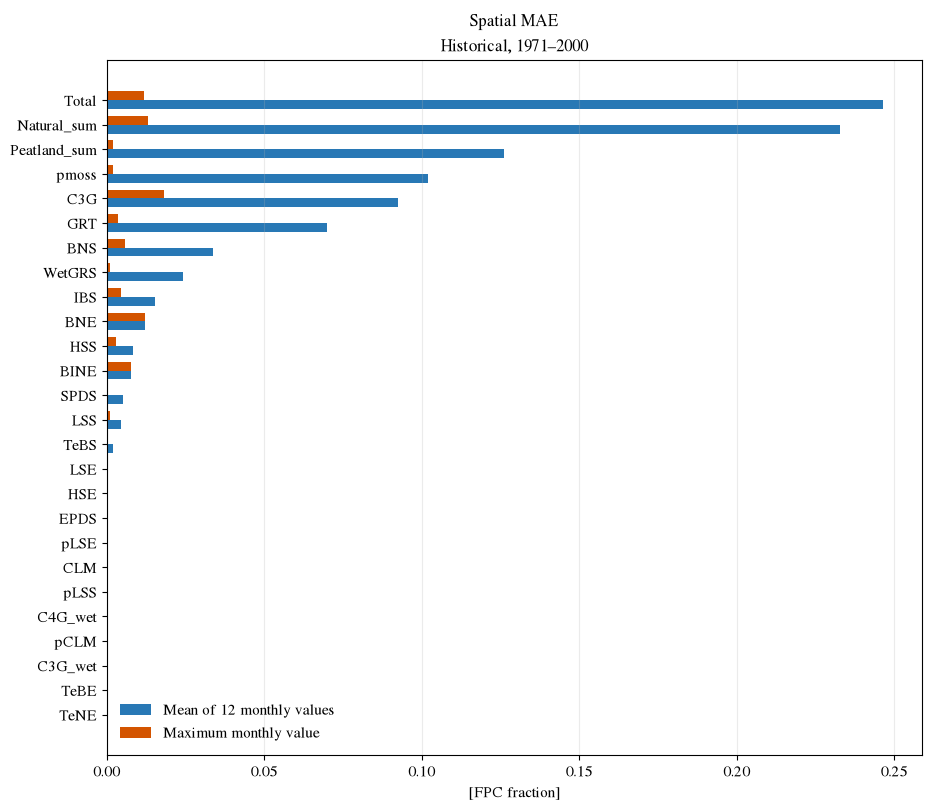

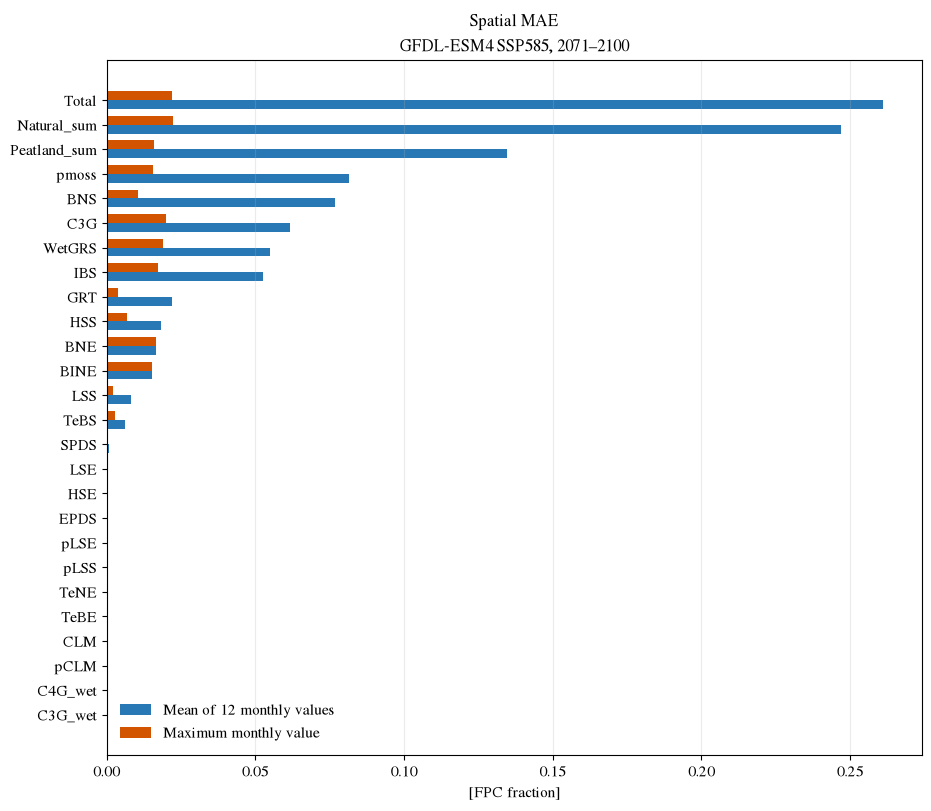

In [17]:
def plot_mae_comparison(period):
    config = PERIODS[period]
    table = datasets[period]["summary"].sort_values("MAE: monthly mean")
    y = np.arange(len(table))
    fig, ax = plt.subplots(figsize=(9.2, 8.0), layout="constrained")
    ax.barh(y - 0.18, table["MAE: monthly mean"], height=0.36,
            color="#2878B5", label="Mean of 12 monthly values")
    ax.barh(y + 0.18, table["MAE: monthly max"], height=0.36,
            color="#D35400", label="Maximum monthly value")
    ax.set(yticks=y, yticklabels=table["field"], xlabel="[FPC fraction]",
           title=f"Spatial MAE\n{config['label']}, {config['start_year']}–{config['end_year']}")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(frameon=False)
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"{period}_mae_monthly_mean_vs_max.png", dpi=200)
    plt.show()


for period in PERIODS:
    plot_mae_comparison(period)


## 6. Find the closest calendar month

This does not assume that the annual output is a monthly maximum. It independently identifies which climatological month has the lowest spatial MAE relative to the year-end structural file.


In [21]:
best_month_parts = []

for period, data in datasets.items():
    candidates = data["monthly"].merge(
        data["annual"][KEYS + data["fields"]], on=KEYS,
        suffixes=("_monthly", "_annual_file"), validate="many_to_one",
    )
    rows = []
    for field in data["fields"]:
        error = (candidates[f"{field}_monthly"] - candidates[f"{field}_annual_file"]).abs()
        by_month = error.groupby(candidates["Month"]).mean()
        best_month = int(by_month.idxmin())
        rows.append({"field": field, "best matching month": best_month,
                     "MAE in best month": by_month.loc[best_month]})
    best_month_parts.append(pd.DataFrame(rows).assign(period=PERIODS[period]["label"]))

best_months = pd.concat(best_month_parts, ignore_index=True)
display(
    best_months.loc[best_months["field"].isin(MAP_FIELDS)]# + EVERGREEN_PFTS)]
    .sort_values(["field", "period"])
    .round(4)
)


,field,best matching month,MAE in best month,period
50,Natural_sum,8,0.0224,GFDL-ESM4 SSP585
24,Natural_sum,8,0.0135,Historical
51,Peatland_sum,8,0.0160,GFDL-ESM4 SSP585
25,Peatland_sum,8,0.0020,Historical
49,Total,8,0.0219,GFDL-ESM4 SSP585
23,Total,8,0.0121,Historical


## 7. Signed-difference maps

The upper half shows **monthly mean − annual file** and the lower half shows **monthly maximum − annual file**. A shared symmetric scale is used within each figure and clipped at the selected percentile only for display; maximum absolute differences remain available in the summary table.


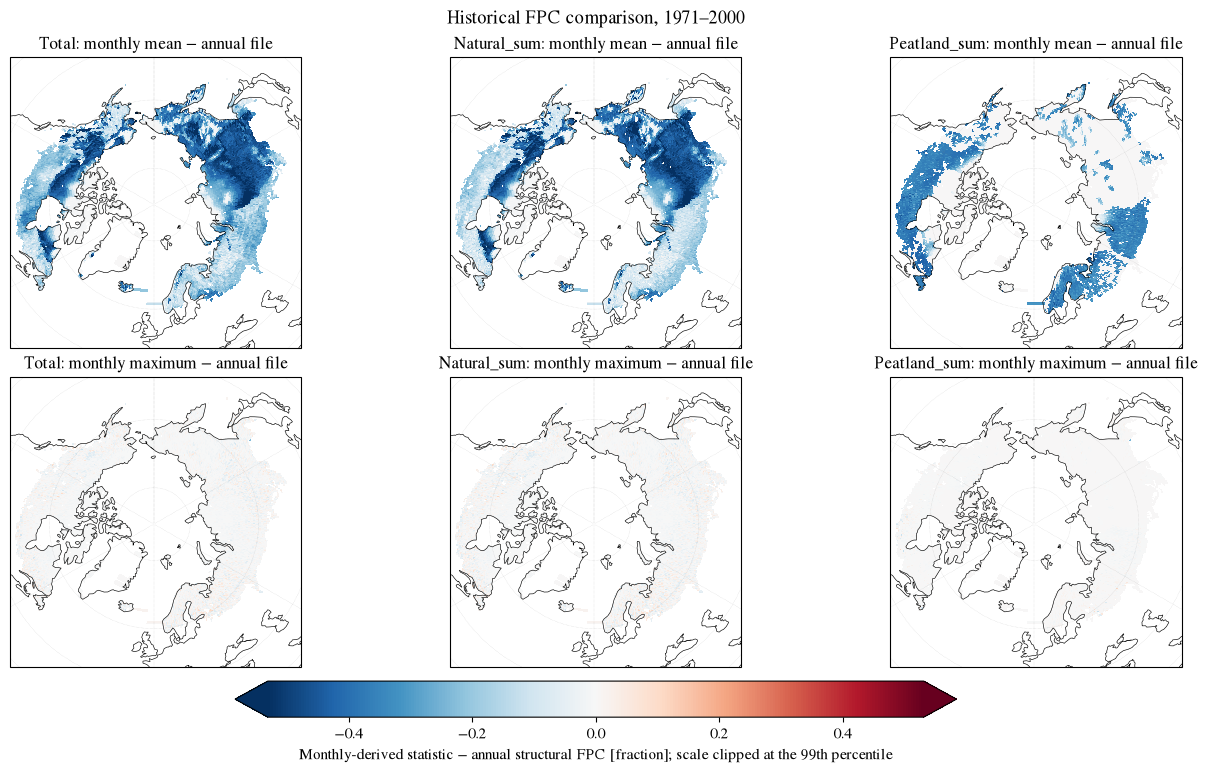

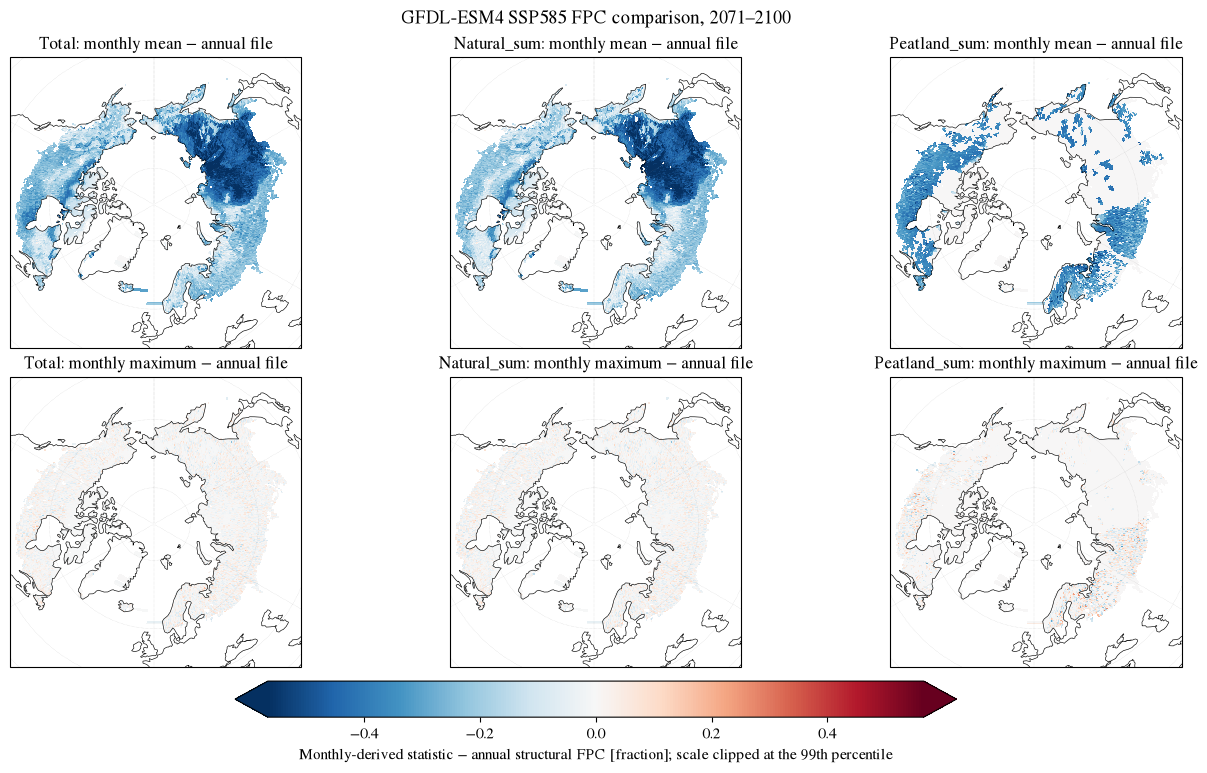

In [11]:
def difference_grid(period, field, statistic):
    if statistic not in {"mean", "max"}:
        raise ValueError("statistic must be 'mean' or 'max'")
    comparison = datasets[period]["comparison"]
    column = f"{field}_{statistic}_difference"
    if column not in comparison:
        raise KeyError(f"Unknown field {field!r}; choose from {datasets[period]['fields']}")
    return comparison.pivot(index="Lat", columns="Lon", values=column).sort_index().sort_index(axis=1)


def draw_map(ax, grid, norm, title):
    if HAS_CARTOPY:
        image = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), cmap="RdBu_r",
                              norm=norm, shading="auto", transform=ccrs.PlateCarree())
        ax.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.45)
        ax.gridlines(linewidth=0.35, color="0.5", alpha=0.4, linestyle=":")
    else:
        image = ax.pcolormesh(grid.columns, grid.index, grid.to_numpy(), cmap="RdBu_r",
                              norm=norm, shading="auto", rasterized=True)
        ax.set(xlim=(-180, 180), ylim=(45, 90), xlabel="Longitude", ylabel="Latitude")
        ax.grid(alpha=0.2, linewidth=0.4)
    ax.set_title(title)
    return image


def plot_comparison_maps(period, fields=MAP_FIELDS, filename=None, percentile=99, ncols=3):
    config = PERIODS[period]
    fields = [field for field in fields if field in datasets[period]["fields"]]
    if not fields:
        raise ValueError("None of the requested fields occurs in this period.")
    ncols = min(ncols, len(fields))
    rows_per_statistic = math.ceil(len(fields) / ncols)
    nrows = 2 * rows_per_statistic
    grids = {(field, statistic): difference_grid(period, field, statistic)
             for field in fields for statistic in ["mean", "max"]}
    finite = [grid.to_numpy()[np.isfinite(grid.to_numpy())] for grid in grids.values()]
    values = np.concatenate([value for value in finite if value.size])
    vmax = max(float(np.percentile(np.abs(values), percentile)), 1e-12)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    subplot_kw = {"projection": ccrs.Orthographic(0, 90)} if HAS_CARTOPY else {}
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows),
                             subplot_kw=subplot_kw, layout="constrained", squeeze=False)

    for index, field in enumerate(fields):
        row, column = divmod(index, ncols)
        mean_grid = grids[(field, "mean")]
        max_grid = grids[(field, "max")]
        image = draw_map(axes[row, column], mean_grid, norm,
                         f"{field}: monthly mean − annual file")
        draw_map(axes[row + rows_per_statistic, column], max_grid, norm,
                 f"{field}: monthly maximum − annual file")

    for index in range(len(fields), rows_per_statistic * ncols):
        row, column = divmod(index, ncols)
        axes[row, column].set_visible(False)
        axes[row + rows_per_statistic, column].set_visible(False)

    colorbar = fig.colorbar(image, ax=axes, orientation="horizontal", shrink=0.55,
                            pad=0.02, extend="both")
    colorbar.set_label(
        f"Monthly-derived statistic − annual structural FPC [fraction]; "
        f"scale clipped at the {percentile}th percentile"
    )
    fig.suptitle(f"{config['label']} FPC comparison, {config['start_year']}–{config['end_year']}")
    if SAVE_FIGURES:
        filename = filename or f"{period}_aggregate_difference_maps.png"
        fig.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()


for period in PERIODS:
    plot_comparison_maps(period)


## 8. Seasonal PFT maps

These fields are useful for diagnosing the effect of deciduous and herbaceous phenology. Comment out this cell if only the aggregate maps are needed.


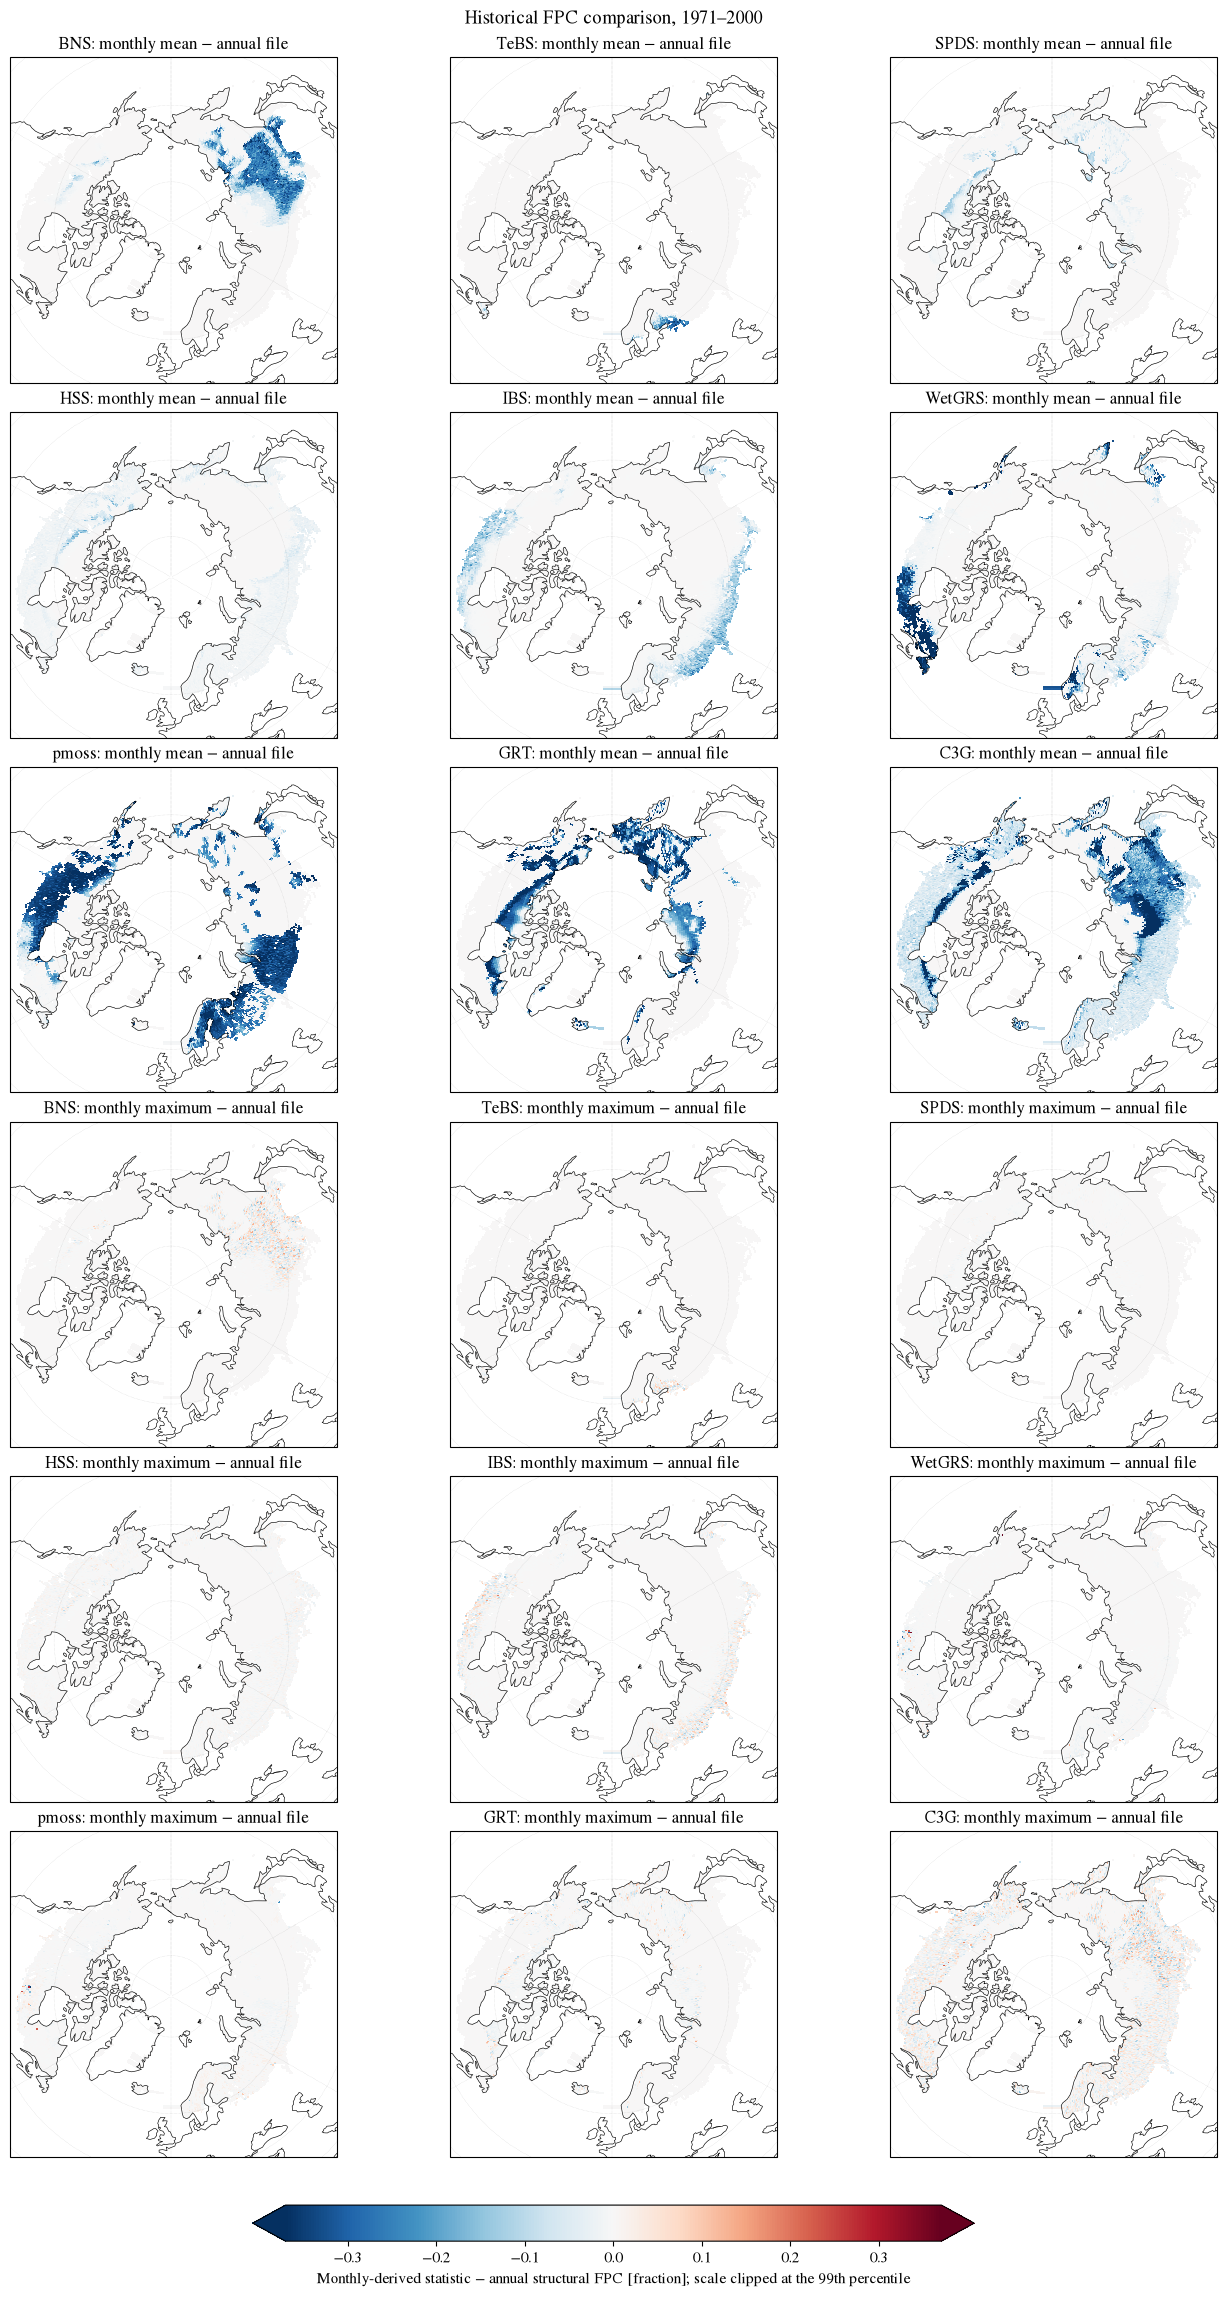

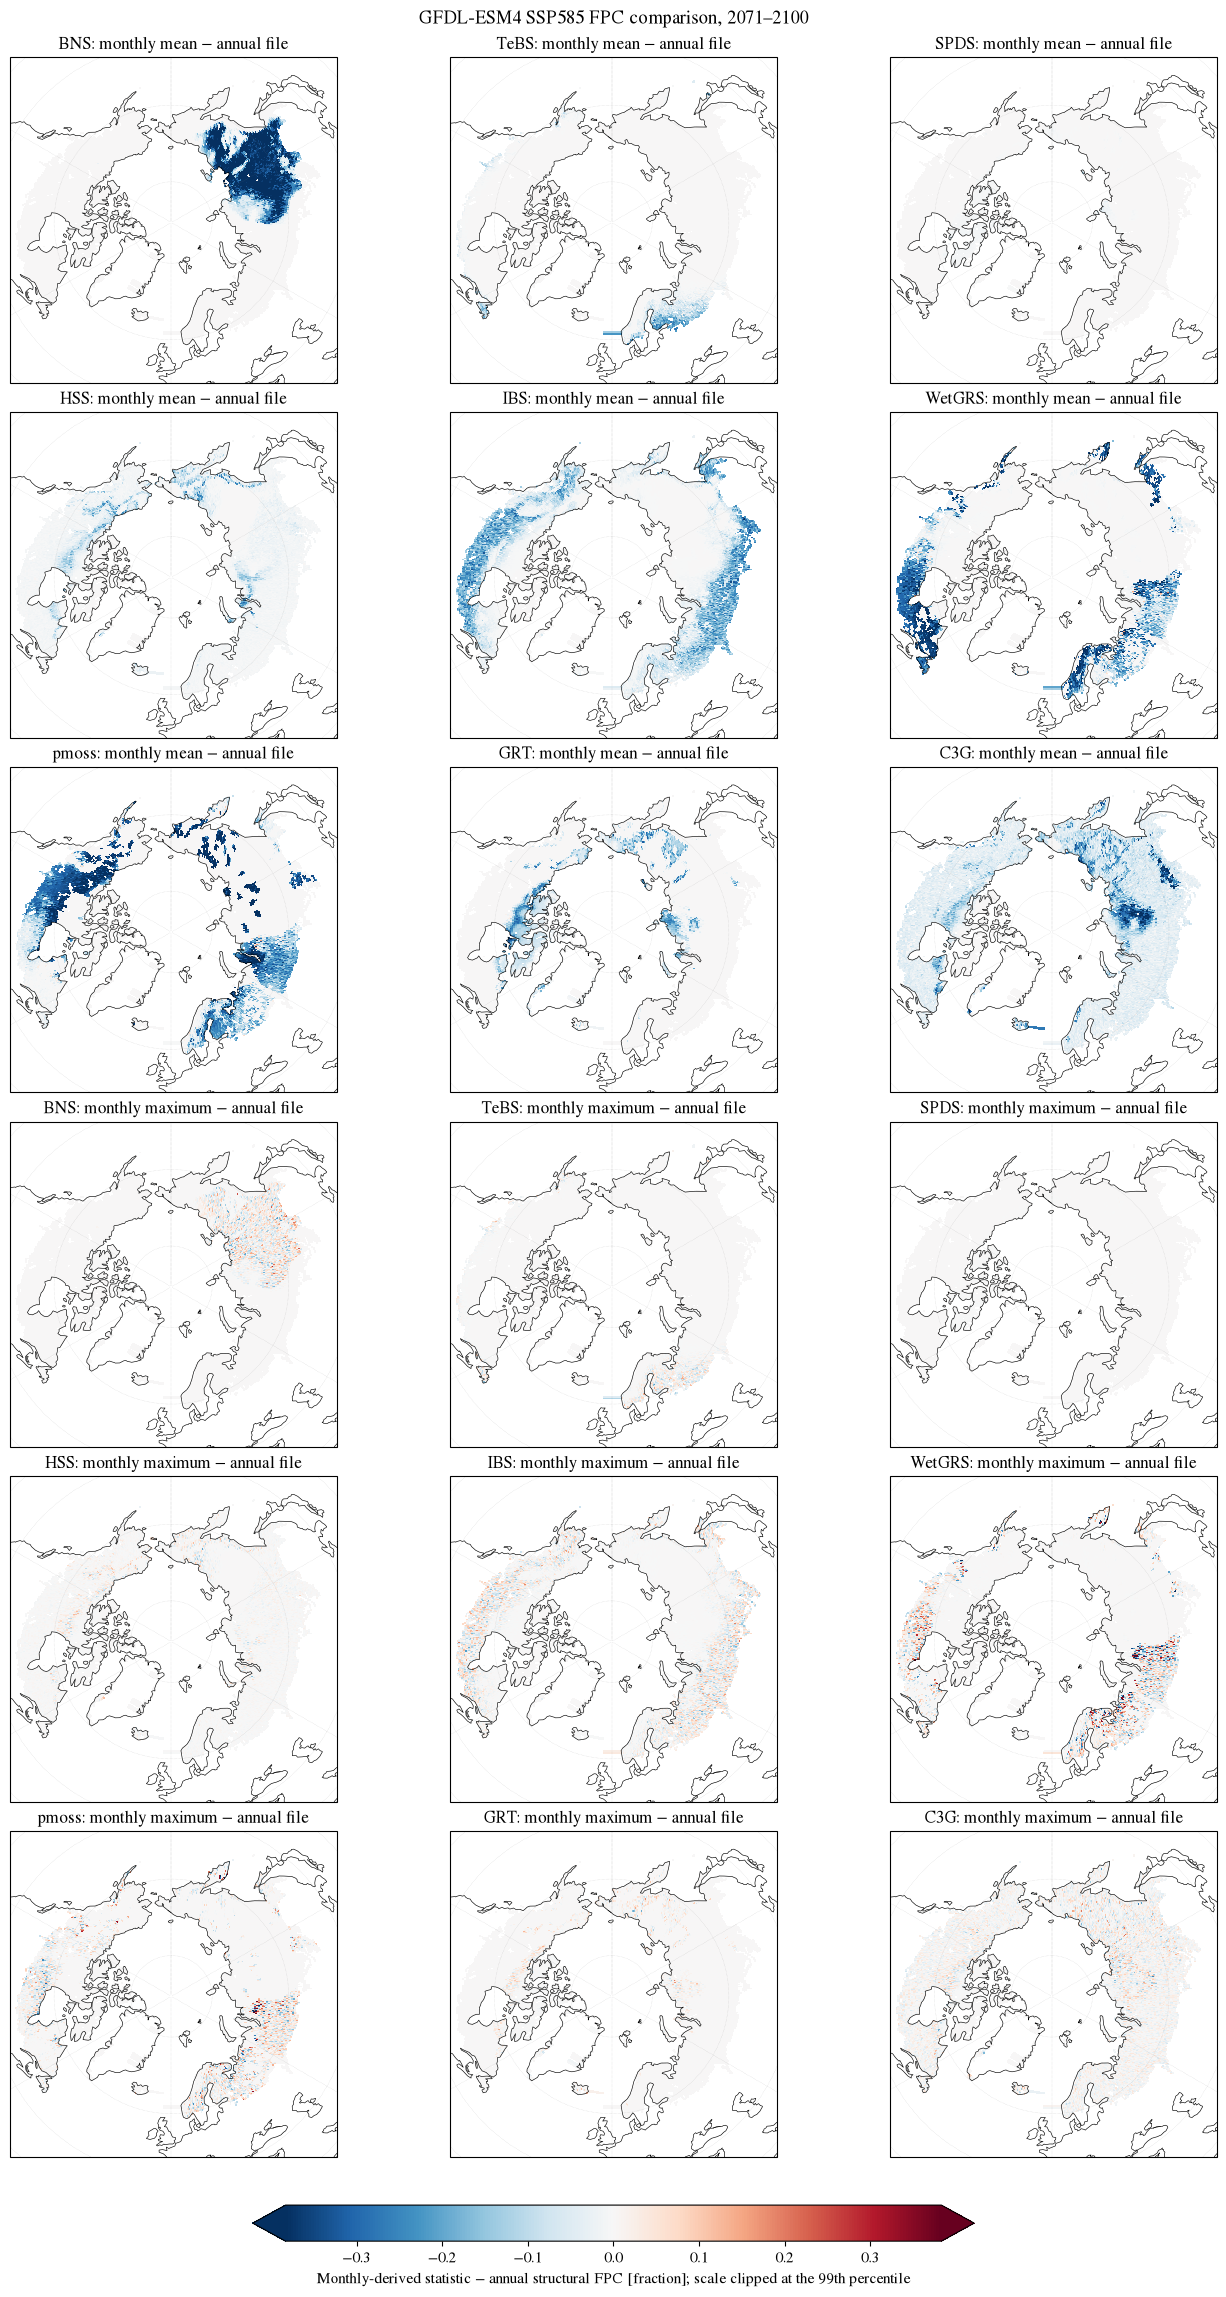

In [12]:
for period in PERIODS:
    plot_comparison_maps(
        period, SEASONAL_FIELDS,
        filename=f"{period}_seasonal_pft_difference_maps.png",
    )


## 9. Evergreen December diagnostic

For evergreen PFTs, the phenology factor is expected to remain close to one. December monthly values should therefore be much closer to the annual structural values than the 12-month mean. This is a stronger diagnostic at individual-PFT level than for `Total`, which mixes evergreen, deciduous, herbaceous, and peatland vegetation.

Small residual differences can remain because a monthly value averages all days, while the annual diagnostic is written at a specific point in the year-end update sequence.


In [13]:
evergreen_rows = []

for period, data in datasets.items():
    available = [field for field in EVERGREEN_PFTS if field in data["fields"]]
    december = data["monthly"].loc[data["monthly"]["Month"] == 12, KEYS + available]
    joined = december.merge(
        data["annual"][KEYS + available], on=KEYS,
        suffixes=("_december", "_annual"), validate="one_to_one",
    )
    for field in available:
        difference = joined[f"{field}_december"] - joined[f"{field}_annual"]
        evergreen_rows.append({
            "period": PERIODS[period]["label"],
            "field": field,
            "December bias": difference.mean(),
            "December MAE": difference.abs().mean(),
            "December RMSE": np.sqrt(np.mean(difference**2)),
            "maximum absolute difference": difference.abs().max(),
        })

evergreen_december_summary = pd.DataFrame(evergreen_rows)
display(evergreen_december_summary.round(5))


,period,field,December bias,December MAE,December RMSE,maximum absolute difference
0,Historical,BNE,-0.00035,0.01233,0.02467,0.16786
1,Historical,BINE,-0.00027,0.00776,0.01649,0.13741
2,Historical,TeNE,0.00000,0.00000,0.00000,0.00000
3,GFDL-ESM4 SSP585,BNE,-0.00028,0.01669,0.02918,0.19828
4,GFDL-ESM4 SSP585,BINE,-0.00025,0.01517,0.02671,0.19686
5,GFDL-ESM4 SSP585,TeNE,-0.00000,0.00001,0.00015,0.01351


## 10. Takeaways

- The mean of the 12 phenology-adjusted monthly values estimates average realised cover through the year; it should not be expected to reproduce the year-end structural FPC.
- A widespread negative monthly-mean difference is therefore a temporal-definition effect, not automatically an error or bias in the monthly output.
- The monthly maximum can resemble the annual structural value because phenology approaches one during peak foliage, but `maximum of monthly climatology` and `mean of year-end structural values` remain different operations.
- Historical–future anomalies must use the same temporal operator in both periods. Do not mix a monthly annual mean for one period with a structural or peak-state value for the other.
- For the most direct consistency check, inspect December evergreen PFTs separately and confirm the exact LPJ-GUESS output/update timing if small offsets remain.
